# Model Comparison V3 - Stock-Aware Sentiment + Binary vs 3-class

**Doel**: voorspel stock direction met dezelfde modellen als V2, met **twee
nieuwe ingredienten**:

1. **LLM-based tweet → stock impact scoring**: elke tweet krijgt voor elke
   stock in `DimStock` een impact-score tussen 0 en 1. Sentiment wordt dan
   per stock geaggregeerd (gewogen naar impact), in plaats van market-wide.
2. **Binary vs 3-class target vergelijking**: we trainen alle modellen in
   beide modes en vergelijken de resultaten side-by-side.
   - **Binary**: 0 = down, 1 = up
   - **3-class**: 0 = down (return < -0.5%), 1 = neutral, 2 = up (return > 0.5%)

## Wat is hetzelfde als V2

- Database tabellen, queries, defensive joins
- VADER sentiment + tekst-features (ticker mentions, ALL-CAPS, keywords)
- Macro-economische features uit `FactEcon`
- Engineered price features (RSI, Bollinger, rolling stats)
- Tijds-gebaseerde train/val/test split
- Modellen: LogReg, RF, XGBoost, LightGBM, MLP, 1D-CNN, GRU, LSTM, CNN+LSTM
- Per-model per-stock plots en confusion matrices

## Wat is anders

- **Sectie 6**: nieuw - LLM impact scoring met sentence-transformer
- **Sectie 7**: aangepast - sentiment per (Date, Stock) ipv per Date
- **Sectie 9**: nieuw - twee targets gedefinieerd
- **Sectie 13-15**: alle modellen worden **2x** getraind (binary + 3-class)
- **Sectie 17**: nieuw - binary vs 3-class side-by-side comparison

## Setup notes

```bash
pip install sentence-transformers
```

> Tip: voor je commit, doe **Cell - All Output - Clear** in Jupyter.

## 1. Setup & imports

In [1]:
import os, sys, json, warnings, time, re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "comparison" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = Path(PROJECT_ROOT) / "model" / "comparison" / "artifacts_v3_v3"
PER_STOCK = ARTIFACTS / "per_stock"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PER_STOCK.mkdir(parents=True, exist_ok=True)
print("Artifacts:", ARTIFACTS)

Artifacts: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v3_v3


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, brier_score_loss,
    confusion_matrix, classification_report,
)
from sklearn.dummy import DummyClassifier

def _try_import(name):
    try: return __import__(name), True
    except ImportError: return None, False

xgb, HAS_XGB = _try_import("xgboost")
lgb, HAS_LGB = _try_import("lightgbm")

# Torch sanity check: import alleen werkt niet altijd - we testen een echte
# torch operatie (Adam optimizer maken) want sommige torch installaties
# crashen pas bij torch.optim of torch._dynamo lazy imports.
HAS_TORCH = False
torch = None
try:
    import torch as _torch
    import torch.nn as _nn
    # Minimale sanity test: maak een optimizer aan
    _p = _nn.Parameter(_torch.zeros(1))
    _opt = _torch.optim.Adam([_p], lr=1e-3)
    _opt.step()  # roept de problematische code paths aan
    torch = _torch
    HAS_TORCH = True
except Exception as _e:
    print(f"PyTorch is geinstalleerd maar werkt niet correct: {type(_e).__name__}: {str(_e)[:120]}")
    print("=> Sequence modellen (CNN/GRU/LSTM/CNN+LSTM) worden geskipt.")
    print("   Fix:  pip uninstall torch -y && pip install --no-cache-dir 'torch>=2.3,<2.6'")

print(f"XGBoost:  {'OK' if HAS_XGB else 'MISSING'}")
print(f"LightGBM: {'OK' if HAS_LGB else 'MISSING'}")
print(f"PyTorch:  {'OK' if HAS_TORCH else 'BROKEN (skip sequence models)'}")

XGBoost:  OK
LightGBM: OK
PyTorch:  OK


In [3]:
# VADER sentiment
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True
    vader = SentimentIntensityAnalyzer()
except ImportError:
    HAS_VADER = False
    print("pip install vaderSentiment")

# Sentence-transformer voor stock-tweet impact (de 'LLM').
# We catchen ALLE exceptions (niet alleen ImportError) want torch/transformers
# version mismatch geeft AttributeError of ModuleNotFoundError uit lazy imports.
HAS_ST = False
try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except Exception as _e:
    print(f"sentence-transformers niet bruikbaar ({type(_e).__name__}: {str(_e)[:100]})")
    print("=> Notebook valt automatisch terug op TF-IDF cosine similarity.")
    print("   Wil je de echte LLM versie? Run in je venv:")
    print("     pip install --upgrade torch transformers sentence-transformers")

# TF-IDF altijd beschikbaar (sklearn) - we gebruiken het als fallback
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
HAS_TFIDF = True

print(f"VADER:                {'OK' if HAS_VADER else 'MISSING'}")
print(f"Sentence-Transformer: {'OK' if HAS_ST else 'OFF -> TF-IDF fallback'}")
print(f"TF-IDF fallback:      {'OK' if HAS_TFIDF else 'MISSING'}")

VADER:                OK
Sentence-Transformer: OK
TF-IDF fallback:      OK


## 2. Database connectie

In [4]:
from database.connectie.connectie import get_engine, getData
engine = get_engine()

with engine.connect() as conn:
    from sqlalchemy import text
    n = conn.execute(text("SELECT COUNT(*) FROM FactMarketData")).scalar()
    print(f"FactMarketData rijen: {n:,}")

def get_or_die(query, name):
    df = getData(engine=engine, query=query)
    if df is None:
        raise RuntimeError(f"Query '{name}' faalde")
    return df

FactMarketData rijen: 470,206


## 3. Market data + macro econ

In [5]:
SQL_MARKET = '''
SELECT
    m.DateKey,
    d.FullDateAlternateKey                              AS [Date],
    LTRIM(RTRIM(m.StockKey))                            AS StockKey,
    COALESCE(NULLIF(LTRIM(RTRIM(s.StockName)), ''),
             LTRIM(RTRIM(m.StockKey)))                  AS StockName,
    s.[Type]                                            AS StockType,
    CAST(m.[Open]  AS FLOAT) AS [Open],
    CAST(m.High    AS FLOAT) AS High,
    CAST(m.Low     AS FLOAT) AS Low,
    CAST(m.[Close] AS FLOAT) AS [Close],
    CAST(m.Volume  AS FLOAT) AS Volume,
    CAST(e.USD                  AS FLOAT) AS USD,
    CAST(e.OIL                  AS FLOAT) AS OIL,
    CAST(e.VIX                  AS FLOAT) AS VIX,
    CAST(e.YieldSpread          AS FLOAT) AS YieldSpread,
    CAST(e.InfExpectation       AS FLOAT) AS InfExpectation,
    CAST(e.FinStress            AS FLOAT) AS FinStress,
    CAST(e.FedFundsRate         AS FLOAT) AS FedFundsRate,
    CAST(e.FedBalanceSheet      AS FLOAT) AS FedBalanceSheet,
    CAST(e.CPI                  AS FLOAT) AS CPI,
    CAST(e.PPI                  AS FLOAT) AS PPI,
    CAST(e.Consumer_Confidence  AS FLOAT) AS Consumer_Confidence
FROM FactMarketData m
JOIN DimDate     d ON d.DateKey = m.DateKey
LEFT JOIN DimStock s ON LTRIM(RTRIM(s.StockKey)) = LTRIM(RTRIM(m.StockKey))
LEFT JOIN FactEcon e ON e.DateKey = m.DateKey
WHERE m.StockKey IS NOT NULL AND LEN(LTRIM(RTRIM(m.StockKey))) > 0
ORDER BY m.StockKey, d.FullDateAlternateKey
'''
market_df = get_or_die(SQL_MARKET, "market")
market_df["Date"] = pd.to_datetime(market_df["Date"])
market_df["stock_id"] = market_df["StockName"].fillna(market_df["StockKey"]).astype(str)
print(f"market_df: {len(market_df):,} rijen, {market_df['stock_id'].nunique()} stocks")
print(f"Periode:   {market_df['Date'].min().date()} -> {market_df['Date'].max().date()}")

market_df: 470,856 rijen, 181 stocks
Periode:   2016-01-04 -> 2026-05-12


## 4. Tekst van tweets en nieuws ophalen

In [6]:
SQL_TWEETS = '''
SELECT d.FullDateAlternateKey AS [Date],
       t.[Text],
       COALESCE(CAST(t.influenceScore AS FLOAT), 0) AS influence
FROM DimTwitter t
JOIN DimDate d ON d.DateKey = t.DateKey
WHERE t.[Text] IS NOT NULL AND LEN(t.[Text]) > 0
'''
SQL_NEWS = '''
SELECT d.FullDateAlternateKey AS [Date],
       COALESCE(n.Headline, '') + ' ' + COALESCE(n.Abstract, '') AS [Text],
       COALESCE(CAST(n.influenceScore AS FLOAT), 0) AS influence
FROM FactNews n
JOIN DimDate d ON d.DateKey = n.DateKey
WHERE (n.Headline IS NOT NULL OR n.Abstract IS NOT NULL)
'''
tweets_df = get_or_die(SQL_TWEETS, "tweets").reset_index(drop=True)
news_df   = get_or_die(SQL_NEWS,   "news").reset_index(drop=True)
tweets_df["Date"] = pd.to_datetime(tweets_df["Date"])
news_df["Date"]   = pd.to_datetime(news_df["Date"])
print(f"tweets: {len(tweets_df):,}  |  news: {len(news_df):,}")

tweets: 56,458  |  news: 253,014


## 5. VADER sentiment scoring + tekst-features

In [7]:
BULLISH = {"rally","surge","beat","upgrade","outperform","bullish",
           "growth","soar","jump","gain","record","strong","profit"}
BEARISH = {"crash","plunge","miss","downgrade","underperform","bearish",
           "decline","fall","drop","loss","weak","warning","lawsuit",
           "investigation","default","bankruptcy"}

TICKER_RE = re.compile(r"\$[A-Z]{1,5}\b")
WORD_RE   = re.compile(r"\b[a-zA-Z']+\b")
EXCL_RE   = re.compile(r"!")

def text_features(t):
    if not isinstance(t, str) or not t:
        return {"v_compound":0,"v_pos":0,"v_neg":0,"v_neu":1,
                "n_tickers":0,"n_excl":0,"caps_ratio":0,"n_words":0,"n_bull":0,"n_bear":0}
    v = vader.polarity_scores(t) if HAS_VADER else {"compound":0,"pos":0,"neg":0,"neu":1}
    words = WORD_RE.findall(t)
    n_words = len(words)
    caps = sum(1 for w in words if len(w)>1 and w.isupper())
    caps_ratio = caps/n_words if n_words else 0
    lower = t.lower()
    return {"v_compound":v["compound"],"v_pos":v["pos"],"v_neg":v["neg"],"v_neu":v["neu"],
            "n_tickers":len(TICKER_RE.findall(t)),"n_excl":len(EXCL_RE.findall(t)),
            "caps_ratio":caps_ratio,"n_words":n_words,
            "n_bull":sum(1 for kw in BULLISH if kw in lower),
            "n_bear":sum(1 for kw in BEARISH if kw in lower)}

def score_df(df):
    feats = pd.DataFrame.from_records(df["Text"].map(text_features).tolist(), index=df.index)
    return pd.concat([df, feats], axis=1)  # let op: we behouden Text voor LLM scoring

print("Scoring tweets..."); t0 = time.time()
tweets_scored = score_df(tweets_df)
print(f"  done in {time.time()-t0:.1f}s")
print("Scoring news...");   t0 = time.time()
news_scored   = score_df(news_df)
print(f"  done in {time.time()-t0:.1f}s")

Scoring tweets...
  done in 10.3s
Scoring news...
  done in 38.8s


## 6. LLM-based tweet → stock impact scoring  *(NEW in V3)*

We willen elke tweet koppelen aan elke stock met een impact score in [0, 1],
waarbij 1 = 100% impact (tweet gaat duidelijk over deze stock), 0 = geen impact.

**Aanpak**: in plaats van een dure LLM API, gebruiken we een **sentence
transformer** (`all-MiniLM-L6-v2`, ~80MB, draait op CPU). Voor elke stock
maken we een korte beschrijving (naam + ticker + type), encoden we beide,
en berekenen we de cosine-similarity. Dit benadert wat een echte LLM zou
doen voor een fractie van de kosten.

**Combineren met direct ticker-match**: als een tweet expliciet een ticker
of stocknaam noemt, krijgt die stock automatisch een hoge impact-score
(0.95). Dat is een betrouwbaarder signaal dan pure embedding-similariteit.

In [8]:
# Bouw stock descriptors
stocks_meta = market_df.groupby("stock_id").first()[["StockKey","StockName","StockType"]].reset_index()
stocks_meta = stocks_meta.fillna("")

def stock_descriptor(row):
    parts = []
    if row["StockName"]: parts.append(str(row["StockName"]))
    if row["StockKey"] and row["StockKey"] != row["StockName"]:
        parts.append(f"ticker symbol {row['StockKey']}")
    if row["StockType"]:
        parts.append(f"type {row['StockType']}")
    parts.append("stock financial market")
    return " ".join(p.strip() for p in parts if p)

stocks_meta["descriptor"] = stocks_meta.apply(stock_descriptor, axis=1)
print("Stock descriptors:")
for _, r in stocks_meta.iterrows():
    print(f"  {r['stock_id']:30s} -> {r['descriptor']}")

Stock descriptors:
  3M Company                     -> 3M Company ticker symbol MMM type EQUITY stock financial market
  AEX-Index                      -> AEX-Index ticker symbol ^AEX type INDEX stock financial market
  AMC Entertainment Holdings, Inc. -> AMC Entertainment Holdings, Inc. ticker symbol AMC type EQUITY stock financial market
  ASML Holding N.V.              -> ASML Holding N.V. ticker symbol ASML.AS type EQUITY stock financial market
  AT&T Inc.                      -> AT&T Inc. ticker symbol T type EQUITY stock financial market
  AXA SA                         -> AXA SA ticker symbol CS.PA type EQUITY stock financial market
  AbbVie Inc.                    -> AbbVie Inc. ticker symbol ABBV type EQUITY stock financial market
  Abbott Laboratories            -> Abbott Laboratories ticker symbol ABT type EQUITY stock financial market
  Adobe Inc.                     -> Adobe Inc. ticker symbol ADBE type EQUITY stock financial market
  Advanced Micro Devices, Inc.   -> Adva

In [9]:
# Bereken impact matrix [n_tweets x n_stocks]
n_tweets = len(tweets_df)
n_stocks = len(stocks_meta)
print(f"Computing impact matrix: {n_tweets:,} tweets x {n_stocks} stocks = {n_tweets * n_stocks:,} pairs")

method = None
if HAS_ST:
    print("Loading sentence-transformer 'all-MiniLM-L6-v2' (eerste keer downloadt het model)...")
    try:
        st_model = SentenceTransformer("all-MiniLM-L6-v2")
        print("Encoding stock descriptors...")
        stock_emb = st_model.encode(stocks_meta["descriptor"].tolist(),
                                     normalize_embeddings=True, show_progress_bar=False)
        print(f"Stock embeddings: {stock_emb.shape}")
        print("Encoding tweets (kan een paar minuten duren op CPU)...")
        t0 = time.time()
        tweet_emb = st_model.encode(tweets_df["Text"].tolist(),
                                     normalize_embeddings=True, batch_size=64,
                                     show_progress_bar=True)
        print(f"Tweet embeddings: {tweet_emb.shape}  ({time.time()-t0:.1f}s)")
        impact = np.clip(tweet_emb @ stock_emb.T, 0, 1).astype(np.float32)
        method = "sentence-transformer"
    except Exception as _e:
        print(f"Sentence-transformer encode faalde ({type(_e).__name__}: {str(_e)[:80]})")
        print("Fallback naar TF-IDF.")
        HAS_ST = False

if not HAS_ST:
    print("TF-IDF cosine similarity scoring (geen torch nodig)...")
    t0 = time.time()
    all_texts = list(tweets_df["Text"].fillna("")) + list(stocks_meta["descriptor"])
    tfidf = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=20_000,
        min_df=2,
        stop_words="english",
    ).fit(all_texts)
    tweet_tfidf = tfidf.transform(tweets_df["Text"].fillna(""))
    stock_tfidf = tfidf.transform(stocks_meta["descriptor"])
    impact = sk_cosine(tweet_tfidf, stock_tfidf).astype(np.float32)
    impact = np.clip(impact, 0, 1)
    print(f"TF-IDF impact matrix: {impact.shape}  ({time.time()-t0:.1f}s)")
    method = "tf-idf"

print(f"Method: {method}")
print(f"Impact matrix shape: {impact.shape}")
print(f"Mean impact: {impact.mean():.3f}, max: {impact.max():.3f}, min: {impact.min():.3f}")

Computing impact matrix: 56,458 tweets x 181 stocks = 10,218,898 pairs
Loading sentence-transformer 'all-MiniLM-L6-v2' (eerste keer downloadt het model)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2813.10it/s]


Encoding stock descriptors...
Stock embeddings: (181, 384)
Encoding tweets (kan een paar minuten duren op CPU)...


Batches: 100%|██████████| 883/883 [07:05<00:00,  2.08it/s]


Tweet embeddings: (56458, 384)  (425.5s)
Method: sentence-transformer
Impact matrix shape: (56458, 181)
Mean impact: 0.031, max: 0.684, min: 0.000


In [10]:
print("Adding direct mention boost...")
tweet_texts = tweets_df["Text"].fillna("").str.lower()

mention_counts = []

for j, row in stocks_meta.iterrows():
    keys = []

    if row["StockKey"]:
        keys.append(re.escape(str(row["StockKey"]).lower()))

    if row["StockName"]:
        # Pak alleen woorden van >=3 chars uit stockname
        for word in re.findall(r"\b[A-Za-z]{3,}\b", str(row["StockName"])):
            if word.lower() not in {
                "the","inc","ltd","corp","plc",
                "group","company","stock","etf","index"
            }:
                keys.append(re.escape(word.lower()))

    if keys:
        pattern = r"(?:^|[^a-z])(" + "|".join(set(keys)) + r")(?:[^a-z]|$)"

        has_mention = tweet_texts.str.contains(
            pattern,
            regex=True,
            na=False
        ).values

        n_matched = int(has_mention.sum())

        impact[has_mention, j] = np.maximum(
            impact[has_mention, j],
            0.95
        )

        mention_counts.append({
            "stock_id": row["stock_id"],
            "mentions": n_matched
        })

        print(f"  {row['stock_id']:30s} -> {n_matched:>5} direct mentions")


# Top 10
top10 = (
    pd.DataFrame(mention_counts)
    .sort_values("mentions", ascending=False)
    .head(10)
)
print(f"\nImpact matrix na ticker-boost: mean={impact.mean():.3f}, max={impact.max():.3f}")

Adding direct mention boost...
  3M Company                     ->     0 direct mentions
  AEX-Index                      ->     0 direct mentions
  AMC Entertainment Holdings, Inc. ->    63 direct mentions
  ASML Holding N.V.              ->    78 direct mentions
  AT&T Inc.                      ->  9634 direct mentions
  AXA SA                         ->     0 direct mentions
  AbbVie Inc.                    ->     1 direct mentions
  Abbott Laboratories            ->    44 direct mentions
  Adobe Inc.                     ->     0 direct mentions
  Advanced Micro Devices, Inc.   ->    37 direct mentions
  Aedifica NV/SA                 ->     0 direct mentions
  Airbus SE                      ->     3 direct mentions
  Akzo Nobel N.V.                ->    36 direct mentions
  Allianz SE                     ->     1 direct mentions
  Alphabet Inc.                  ->     0 direct mentions
  Amazon.com, Inc.               -> 16470 direct mentions
  American Express Company       ->  29

In [11]:
print("\nTop 10 stocks mentioned:")
print(top10.to_string(index=False))


Top 10 stocks mentioned:
                                       stock_id  mentions
                          Eli Lilly and Company     20819
                               Amazon.com, Inc.     16470
                                      AT&T Inc.      9634
                    Bank of America Corporation      4598
     State Street Energy Select Sector SPDR ETF      3382
State Street Real Estate Select Sector SPDR ETF      3147
State Street Health Care Select Sector SPDR ETF      3016
             American International Group, Inc.      3008
                       American Express Company      2910
              Capital One Financial Corporation      2826


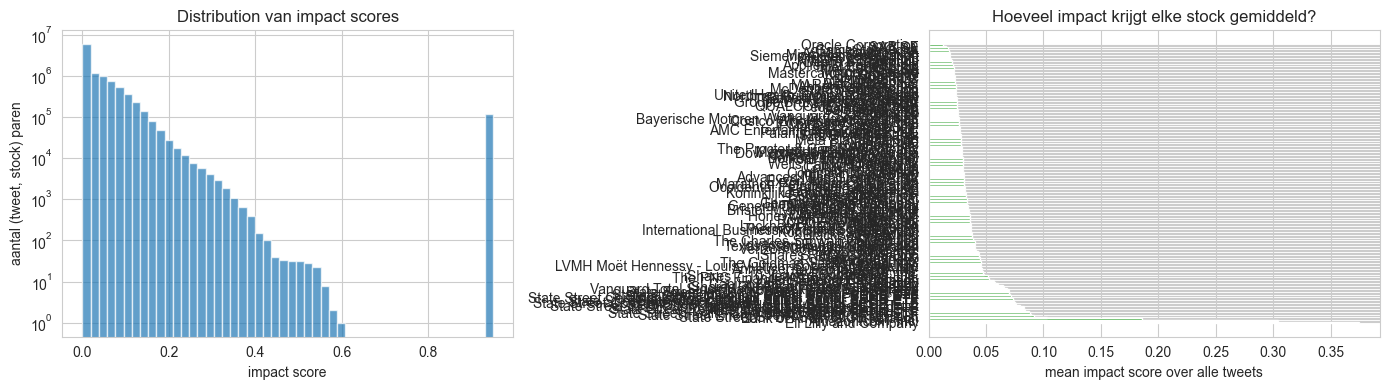

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v3_v3\impact_distribution.png


In [12]:
# Histogram + visualisatie
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(impact.flatten(), bins=50, color="#1f77b4", alpha=0.7)
axes[0].set_xlabel("impact score"); axes[0].set_ylabel("aantal (tweet, stock) paren")
axes[0].set_title("Distribution van impact scores")
axes[0].set_yscale("log")

# Mean impact per stock
mean_impact_per_stock = impact.mean(axis=0)
order = np.argsort(mean_impact_per_stock)[::-1]
axes[1].barh(stocks_meta["stock_id"].values[order], mean_impact_per_stock[order],
             color="#2ca02c")
axes[1].set_xlabel("mean impact score over alle tweets")
axes[1].set_title("Hoeveel impact krijgt elke stock gemiddeld?")
plt.tight_layout()
plt.savefig(ARTIFACTS / "impact_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'impact_distribution.png'}")

## 7. Stock-aware sentiment aggregatie  *(NEW in V3)*

Voor elke (Date, stock) berekenen we sentiment-features waarin elke tweet
gewogen wordt door zijn impact-score voor die stock.

Een tweet die overduidelijk over Apple gaat heeft impact[Apple]=0.95 en
zal sterk meewegen in Apple's daily sentiment, maar nauwelijks in Tesla's.

**News blijft market-wide** — nieuws is moeilijker per ticker te attributeren
omdat er meer context nodig is. We aggregeren news per dag zoals in V2.

In [13]:
# Per stock: weighted aggregation per dag
print("Aggregating tweet sentiment per (date, stock)...")
tweets_scored_with_dnorm = tweets_scored.copy()
tweets_scored_with_dnorm["dnorm"] = tweets_scored_with_dnorm["Date"].dt.normalize()

# Presidential boost: tweets tijdens Trump's ambtsperiodes wegen zwaarder.
# Term 1: 20 jan 2017 - 20 jan 2021. Term 2: 20 jan 2025 - ...
PRESIDENTIAL_BOOST = 2.0   # tijdens president weegt elke tweet 2x meer
_tweet_dates = tweets_scored_with_dnorm["Date"]
_term1 = (_tweet_dates >= "2017-01-20") & (_tweet_dates <= "2021-01-20")
_term2 = _tweet_dates >= "2025-01-20"
_is_pres_tweet = (_term1 | _term2).astype(float).values
_pres_multiplier = 1.0 + (PRESIDENTIAL_BOOST - 1.0) * _is_pres_tweet
print(f"  Presidential boost x{PRESIDENTIAL_BOOST} toegepast op {int(_is_pres_tweet.sum()):,} tweets")

per_stock_records = []
for j, row in stocks_meta.iterrows():
    stock_id = row["stock_id"]
    w_base = impact[:, j].astype(np.float64)  # base impact for this stock
    w = w_base * _pres_multiplier              # boost tijdens presidentschap
    sub = tweets_scored_with_dnorm.copy()
    sub["w"] = w
    sub["w_compound"] = sub["v_compound"] * sub["w"]
    sub["w_pos"] = sub["v_pos"] * sub["w"]
    sub["w_neg"] = sub["v_neg"] * sub["w"]
    sub["w_bull"] = sub["n_bull"] * sub["w"]
    sub["w_bear"] = sub["n_bear"] * sub["w"]
    g = sub.groupby("dnorm").agg(
        sum_w=("w", "sum"),
        n_items=("w", "size"),
        sum_w_compound=("w_compound", "sum"),
        sum_w_pos=("w_pos", "sum"),
        sum_w_neg=("w_neg", "sum"),
        sum_w_bull=("w_bull", "sum"),
        sum_w_bear=("w_bear", "sum"),
        max_w=("w", "max"),
        compound_std=("v_compound", "std"),
    ).reset_index()
    eps = 1e-6
    g["tw_compound_wmean"] = g["sum_w_compound"] / (g["sum_w"] + eps)
    g["tw_pos_wmean"]      = g["sum_w_pos"]      / (g["sum_w"] + eps)
    g["tw_neg_wmean"]      = g["sum_w_neg"]      / (g["sum_w"] + eps)
    g["tw_bull_w"]         = g["sum_w_bull"]
    g["tw_bear_w"]         = g["sum_w_bear"]
    g["tw_total_impact"]   = g["sum_w"]
    g["tw_max_impact"]     = g["max_w"]
    g["tw_n_items"]        = g["n_items"]
    g["tw_compound_std"]   = g["compound_std"].fillna(0)
    g["stock_id"] = stock_id
    per_stock_records.append(g[["dnorm","stock_id","tw_compound_wmean","tw_pos_wmean",
                                 "tw_neg_wmean","tw_bull_w","tw_bear_w",
                                 "tw_total_impact","tw_max_impact","tw_n_items",
                                 "tw_compound_std"]].rename(columns={"dnorm":"Date"}))

tw_per_stock = pd.concat(per_stock_records, ignore_index=True)
print(f"Stock-aware tweet sentiment: {tw_per_stock.shape}")

Aggregating tweet sentiment per (date, stock)...
  Presidential boost x2.0 toegepast op 31,142 tweets
Stock-aware tweet sentiment: (578114, 11)


In [14]:
# News aggregeert market-wide (zoals V2)
news_agg = news_scored.copy()
news_agg["dnorm"] = news_agg["Date"].dt.normalize()
g = news_agg.groupby("dnorm")
news_daily = pd.DataFrame({
    "news_compound_mean": g["v_compound"].mean(),
    "news_compound_std":  g["v_compound"].std().fillna(0),
    "news_pos_sum":       g["v_pos"].sum(),
    "news_neg_sum":       g["v_neg"].sum(),
    "news_n_items":       g.size(),
    "news_bull_sum":      g["n_bull"].sum(),
    "news_bear_sum":      g["n_bear"].sum(),
}).reset_index().rename(columns={"dnorm":"Date"})
print(f"News (market-wide): {news_daily.shape}")

News (market-wide): (3767, 8)


## 8. Joinen + feature engineering

In [15]:
# Merge: market_df + tw_per_stock op (Date, stock_id) + news_daily op Date
df = market_df.merge(tw_per_stock, on=["Date", "stock_id"], how="left")
df = df.merge(news_daily, on="Date", how="left")

# Forward-fill sentiment per stock (sommige dagen geen tweets)
sent_cols = [c for c in df.columns if c.startswith(("tw_","news_"))]
df[sent_cols] = df.sort_values(["stock_id","Date"]).groupby("stock_id")[sent_cols].ffill()
df[sent_cols] = df[sent_cols].fillna(0)
print(f"df na merge: {df.shape}")

df na merge: (470856, 38)


In [16]:
def add_engineered(g):
    g = g.sort_values("Date").copy()
    c = g["Close"]
    g["log_return"]     = np.log(c / c.shift(1))
    g["return_5d"]      = c.pct_change(5)
    g["return_10d"]     = c.pct_change(10)
    g["rolling_mean_5"] = c.rolling(5).mean()
    g["rolling_std_5"]  = c.rolling(5).std()
    g["rolling_std_20"] = c.rolling(20).std()
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    g["rsi_14"] = (100 - 100/(1+rs)).fillna(50)
    m20 = c.rolling(20).mean()
    s20 = c.rolling(20).std().replace(0, np.nan)
    g["bollinger_pos"] = ((c - m20) / s20).fillna(0)
    v = g["Volume"]
    g["vol_zscore"] = ((v - v.rolling(20).mean()) / v.rolling(20).std().replace(0, np.nan)).fillna(0)
    # isPresident: 1 als datum tijdens Trump's ambtstermijn valt
    # Term 1: 20 jan 2017 - 20 jan 2021. Term 2: vanaf 20 jan 2025.
    d = pd.to_datetime(g["Date"])
    _term1 = (d >= "2017-01-20") & (d <= "2021-01-20")
    _term2 = d >= "2025-01-20"
    g["isPresident"] = (_term1 | _term2).astype(int)
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_engineered(_g)
    _g2["stock_id"] = _sid
    _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
print(f"df na engineering: {df.shape}")

df na engineering: (470856, 48)


## 9. Twee targets: binary en 3-class  *(NEW in V3)*

- `target_bin`: 1 als `Close[t+1] > Close[t]` else 0
- `target_3`: 0 (down: return < -0.5%), 1 (neutral), 2 (up: return > +0.5%)

We bewaren ook `y_return` voor regressie-metrics.

In [17]:
HORIZON = 1
THRESHOLD_NEUTRAL = 0.005  # 0.5% — minder dan dit telt als neutral

def add_targets(g):
    g = g.sort_values("Date").copy()
    fut = g["Close"].shift(-HORIZON)
    fut_ret = fut / g["Close"] - 1
    g["y_return"] = fut_ret
    g["target_bin"] = (fut_ret > 0).astype(float)
    # 3-class
    cls = np.full(len(g), np.nan)
    cls[fut_ret < -THRESHOLD_NEUTRAL] = 0  # down
    cls[(fut_ret >= -THRESHOLD_NEUTRAL) & (fut_ret <= THRESHOLD_NEUTRAL)] = 1  # neutral
    cls[fut_ret > THRESHOLD_NEUTRAL] = 2  # up
    g["target_3"] = cls
    g.loc[fut.isna(), ["target_bin", "target_3", "y_return"]] = np.nan
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_targets(_g)
    _g2["stock_id"] = _sid
    _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
df = df.dropna(subset=["target_bin","target_3"]).reset_index(drop=True)
df["target_bin"] = df["target_bin"].astype(int)
df["target_3"]   = df["target_3"].astype(int)

print(f"Final df: {df.shape}")
print(f"\nBinary class balance:")
print(df["target_bin"].value_counts(normalize=True).rename({0:"down",1:"up"}).round(3))
print(f"\n3-class balance:")
print(df["target_3"].value_counts(normalize=True).rename({0:"down",1:"neutral",2:"up"}).sort_index().round(3))

Final df: (470675, 51)

Binary class balance:
target_bin
up      0.519
down    0.481
Name: proportion, dtype: float64

3-class balance:
target_3
down       0.314
neutral    0.334
up         0.351
Name: proportion, dtype: float64


## 10. Tijds-gebaseerde train/val/test split

In [18]:
dates_sorted = np.sort(df["Date"].unique())
n = len(dates_sorted)
TRAIN_END = pd.Timestamp(dates_sorted[int(n*0.75)-1])
VAL_END   = pd.Timestamp(dates_sorted[int(n*0.90)-1])

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df   = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df  = df[df["Date"] > VAL_END].copy()
print(f"Train: {len(train_df):>6,}  ({train_df['Date'].min().date()} -> {TRAIN_END.date()})")
print(f"Val:   {len(val_df):>6,}  ({(TRAIN_END + pd.Timedelta(days=1)).date()} -> {VAL_END.date()})")
print(f"Test:  {len(test_df):>6,}  ({(VAL_END + pd.Timedelta(days=1)).date()} -> {test_df['Date'].max().date()})")

Train: 351,056  (2016-01-04 -> 2023-10-06)
Val:   71,427  (2023-10-07 -> 2025-04-28)
Test:  48,192  (2025-04-29 -> 2026-05-12)


## 11. Feature matrices

In [19]:
META_COLS = {"DateKey","Date","StockKey","StockName","StockType","stock_id",
              "target_bin","target_3","y_return"}
PRICE_FEATURES = ["Open","High","Low","Close","Volume",
                  "log_return","return_5d","return_10d",
                  "rolling_mean_5","rolling_std_5","rolling_std_20",
                  "rsi_14","bollinger_pos","vol_zscore",
                  "USD","OIL","VIX","YieldSpread","InfExpectation",
                  "FinStress","FedFundsRate","FedBalanceSheet","CPI","PPI",
                  "Consumer_Confidence"]
SENT_FEATURES = [c for c in df.columns if c.startswith(("tw_","news_"))]
EXTRA_FEATURES = ["isPresident"]  # event-based feature
EXTRA_FEATURES = [c for c in EXTRA_FEATURES if c in df.columns]
PRICE_FEATURES = [c for c in PRICE_FEATURES if c in df.columns]
FEATURE_COLS = PRICE_FEATURES + SENT_FEATURES + EXTRA_FEATURES
print(f"Price features: {len(PRICE_FEATURES)}  Sentiment: {len(SENT_FEATURES)}  Extra: {len(EXTRA_FEATURES)}")
print(f"Totaal: {len(FEATURE_COLS)}")

Price features: 25  Sentiment: 16  Extra: 1
Totaal: 42


In [20]:
def with_stock_dummies(d):
    return pd.get_dummies(d.copy(), columns=["stock_id"], prefix="stk", drop_first=False)

train_tab = with_stock_dummies(train_df)
val_tab   = with_stock_dummies(val_df)
test_tab  = with_stock_dummies(test_df)
all_cols = sorted(set(train_tab.columns) | set(val_tab.columns) | set(test_tab.columns))
for d in (train_tab, val_tab, test_tab):
    for c in all_cols:
        if c not in d.columns: d[c] = 0
stk_cols = [c for c in train_tab.columns if c.startswith("stk_")]
TAB_FEATURES = FEATURE_COLS + stk_cols

X_tr = np.nan_to_num(train_tab[TAB_FEATURES].astype(float).values)
X_va = np.nan_to_num(val_tab[TAB_FEATURES].astype(float).values)
X_te = np.nan_to_num(test_tab[TAB_FEATURES].astype(float).values)

# Targets - twee versies
y_bin_tr = train_tab["target_bin"].astype(int).values
y_bin_va = val_tab["target_bin"].astype(int).values
y_bin_te = test_tab["target_bin"].astype(int).values
y_3_tr   = train_tab["target_3"].astype(int).values
y_3_va   = val_tab["target_3"].astype(int).values
y_3_te   = test_tab["target_3"].astype(int).values

# Bewaar metadata voor plots
test_stock_ids = test_df["stock_id"].values
test_dates     = test_df["Date"].values
test_close     = test_df["Close"].values

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)
print(f"X_tr: {X_tr.shape}, X_va: {X_va.shape}, X_te: {X_te.shape}")

X_tr: (351056, 223), X_va: (71427, 223), X_te: (48192, 223)


## 12. Evaluatie helpers

We loggen voor elk model alle metrics in beide modes en bewaren ze in
aparte dictionaries `results_bin` en `results_3`.

In [21]:
results_bin = []
results_3   = []
predictions_bin = {}
predictions_3   = {}

def safe_mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def log_binary(name, y_tr_p, y_va_p, y_te_p, y_te_proba,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_bin_tr
    yt_va = y_va_true if y_va_true is not None else y_bin_va
    yt_te = y_te_true if y_te_true is not None else y_bin_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(yt_va, y_va_p)
        rec["val_f1"]  = f1_score(yt_va, y_va_p, zero_division=0)
    rec["test_acc"]  = accuracy_score(yt_te, y_te_p)
    rec["precision"] = precision_score(yt_te, y_te_p, zero_division=0)
    rec["recall"]    = recall_score(yt_te, y_te_p, zero_division=0)
    rec["f1"]        = f1_score(yt_te, y_te_p, zero_division=0)
    if y_te_proba is not None:
        rec["roc_auc"] = roc_auc_score(yt_te, y_te_proba)
        rec["mae"]     = mean_absolute_error(yt_te, y_te_proba)
        rec["mape"]    = safe_mape(yt_te, y_te_proba)
        rec["brier"]   = brier_score_loss(yt_te, y_te_proba)
    results_bin.append(rec)
    print(f"  [BIN] {name:25s}  " + "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float)))
    predictions_bin[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba if y_te_proba is not None else np.full_like(yt_te, 0.5, dtype=float),
    }
    return rec

def log_3class(name, y_tr_p, y_va_p, y_te_p, y_te_proba_mat,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_3_tr
    yt_va = y_va_true if y_va_true is not None else y_3_va
    yt_te = y_te_true if y_te_true is not None else y_3_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(yt_va, y_va_p)
        rec["val_f1_macro"] = f1_score(yt_va, y_va_p, average="macro", zero_division=0)
    rec["test_acc"] = accuracy_score(yt_te, y_te_p)
    rec["precision_macro"] = precision_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["recall_macro"]    = recall_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_macro"]        = f1_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_weighted"]     = f1_score(yt_te, y_te_p, average="weighted", zero_division=0)
    if y_te_proba_mat is not None and y_te_proba_mat.ndim == 2 and y_te_proba_mat.shape[1] == 3:
        try:
            rec["roc_auc_ovr"] = roc_auc_score(yt_te, y_te_proba_mat, multi_class="ovr",
                                                average="macro", labels=[0,1,2])
        except Exception:
            rec["roc_auc_ovr"] = float("nan")
        # MAE op ordinaal verschil tussen voorspelling-class en true-class (0=down,1=neu,2=up)
        rec["mae_ordinal"] = float(np.mean(np.abs(yt_te.astype(float) - y_te_p.astype(float))))
    results_3.append(rec)
    print(f"  [3CL] {name:25s}  " + "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float)))
    predictions_3[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba_mat,
    }
    return rec

## 13. Tabular modellen — BINARY (up/down)

In [22]:
print("=== BINARY ===")
dummy_b = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_bin_tr)
log_binary("Majority class", dummy_b.predict(X_tr_s), dummy_b.predict(X_va_s),
           dummy_b.predict(X_te_s), dummy_b.predict_proba(X_te_s)[:,1])

logreg_b = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_bin_tr)
log_binary("Logistic Regression", logreg_b.predict(X_tr_s), logreg_b.predict(X_va_s),
           logreg_b.predict(X_te_s), logreg_b.predict_proba(X_te_s)[:,1])

rf_b = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_bin_tr)
log_binary("Random Forest", rf_b.predict(X_tr), rf_b.predict(X_va),
           rf_b.predict(X_te), rf_b.predict_proba(X_te)[:,1])

if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_b = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="logloss", n_jobs=-1, random_state=42,
                          scale_pos_weight=(y_bin_tr==0).sum()/max((y_bin_tr==1).sum(),1))
    xgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)], verbose=False)
    log_binary("XGBoost", xgb_b.predict(X_tr), xgb_b.predict(X_va),
               xgb_b.predict(X_te), xgb_b.predict_proba(X_te)[:,1])

if HAS_LGB:
    from lightgbm import LGBMClassifier
    lgb_b = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced")
    lgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)])
    log_binary("LightGBM", lgb_b.predict(X_tr), lgb_b.predict(X_va),
               lgb_b.predict(X_te), lgb_b.predict_proba(X_te)[:,1])

mlp_b = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_bin_tr)
log_binary("MLP", mlp_b.predict(X_tr_s), mlp_b.predict(X_va_s),
           mlp_b.predict(X_te_s), mlp_b.predict_proba(X_te_s)[:,1])

=== BINARY ===
  [BIN] Majority class             train_acc=0.518  val_acc=0.528  val_f1=0.691  test_acc=0.513  precision=0.513  recall=1.000  f1=0.678  roc_auc=0.500  mae=0.487  mape=48703.104  brier=0.487
  [BIN] Logistic Regression        train_acc=0.527  val_acc=0.494  val_f1=0.344  test_acc=0.489  precision=0.511  recall=0.114  f1=0.186  roc_auc=0.510  mae=0.497  mape=22415.433  brier=0.252
  [BIN] Random Forest              train_acc=0.662  val_acc=0.498  val_f1=0.504  test_acc=0.521  precision=0.540  recall=0.443  f1=0.487  roc_auc=0.538  mae=0.498  mape=24135.120  brier=0.249
  [BIN] XGBoost                    train_acc=0.669  val_acc=0.508  val_f1=0.585  test_acc=0.517  precision=0.534  recall=0.450  f1=0.489  roc_auc=0.524  mae=0.496  mape=23500.276  brier=0.252
  [BIN] LightGBM                   train_acc=0.702  val_acc=0.504  val_f1=0.553  test_acc=0.503  precision=0.526  recall=0.329  f1=0.405  roc_auc=0.518  mae=0.497  mape=22587.879  brier=0.256
  [BIN] MLP              

{'model': 'MLP',
 'train_acc': 0.6853892256506084,
 'val_acc': 0.5170033740742296,
 'val_f1': 0.6009969582364711,
 'test_acc': 0.5115994355909694,
 'precision': 0.5189294621730511,
 'recall': 0.6564863880910966,
 'f1': 0.5796588981159032,
 'roc_auc': 0.506301070231371,
 'mae': 0.4930227992016991,
 'mape': 28770.47939016884,
 'brier': 0.335310832536534}

## 14. Tabular modellen — 3-CLASS (down/neutral/up)

In [23]:
print("=== 3-CLASS ===")
dummy_3 = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_3_tr)
log_3class("Majority class", dummy_3.predict(X_tr_s), dummy_3.predict(X_va_s),
           dummy_3.predict(X_te_s), dummy_3.predict_proba(X_te_s))

# multi_class arg verwijderd in sklearn 1.5+; multinomial is automatisch bij >2 classes
logreg_3 = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_3_tr)
log_3class("Logistic Regression", logreg_3.predict(X_tr_s), logreg_3.predict(X_va_s),
           logreg_3.predict(X_te_s), logreg_3.predict_proba(X_te_s))

rf_3 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_3_tr)
log_3class("Random Forest", rf_3.predict(X_tr), rf_3.predict(X_va),
           rf_3.predict(X_te), rf_3.predict_proba(X_te))

if HAS_XGB:
    xgb_3 = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="mlogloss", n_jobs=-1, random_state=42,
                          objective="multi:softprob", num_class=3)
    xgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)], verbose=False)
    log_3class("XGBoost", xgb_3.predict(X_tr), xgb_3.predict(X_va),
               xgb_3.predict(X_te), xgb_3.predict_proba(X_te))

if HAS_LGB:
    lgb_3 = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced",
                           objective="multiclass", num_class=3)
    lgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)])
    log_3class("LightGBM", lgb_3.predict(X_tr), lgb_3.predict(X_va),
               lgb_3.predict(X_te), lgb_3.predict_proba(X_te))

mlp_3 = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_3_tr)
log_3class("MLP", mlp_3.predict(X_tr_s), mlp_3.predict(X_va_s),
           mlp_3.predict(X_te_s), mlp_3.predict_proba(X_te_s))

=== 3-CLASS ===
  [3CL] Majority class             train_acc=0.348  val_acc=0.361  val_f1_macro=0.177  test_acc=0.359  precision_macro=0.120  recall_macro=0.333  f1_macro=0.176  f1_weighted=0.190  roc_auc_ovr=0.500  mae_ordinal=0.957
  [3CL] Logistic Regression        train_acc=0.435  val_acc=0.391  val_f1_macro=0.353  test_acc=0.383  precision_macro=0.410  recall_macro=0.397  f1_macro=0.332  f1_weighted=0.323  roc_auc_ovr=0.587  mae_ordinal=0.848
  [3CL] Random Forest              train_acc=0.523  val_acc=0.379  val_f1_macro=0.371  test_acc=0.368  precision_macro=0.436  recall_macro=0.376  f1_macro=0.326  f1_weighted=0.324  roc_auc_ovr=0.577  mae_ordinal=0.948
  [3CL] XGBoost                    train_acc=0.538  val_acc=0.402  val_f1_macro=0.388  test_acc=0.393  precision_macro=0.394  recall_macro=0.390  f1_macro=0.389  f1_weighted=0.391  roc_auc_ovr=0.578  mae_ordinal=0.856
  [3CL] LightGBM                   train_acc=0.593  val_acc=0.402  val_f1_macro=0.395  test_acc=0.392  precision

{'model': 'MLP',
 'train_acc': 0.5454713777858803,
 'val_acc': 0.3928066417461184,
 'val_f1_macro': 0.3876781849551248,
 'test_acc': 0.3853544156706507,
 'precision_macro': 0.38356241697150795,
 'recall_macro': 0.3854755596107636,
 'f1_macro': 0.37123005452437036,
 'f1_weighted': 0.37201283248725353,
 'roc_auc_ovr': 0.5590121749634548,
 'mae_ordinal': 0.7878693559096945}

## 15. Sequence-data preparen (voor beide modes)

In [24]:
SEQ_LEN = 20

def build_sequences(d, target_col):
    Xs, ys, sids, dts, closes = [], [], [], [], []
    stock_id_map = {s: i for i, s in enumerate(sorted(d["stock_id"].unique()))}
    for sid_str, g in d.groupby("stock_id", sort=False):
        g = g.sort_values("Date").reset_index(drop=True)
        if len(g) < SEQ_LEN: continue
        a = np.nan_to_num(g[FEATURE_COLS].astype(float).values)
        t = g[target_col].astype(int).values
        d_arr = g["Date"].values
        c_arr = g["Close"].values
        for end in range(SEQ_LEN, len(g)):
            Xs.append(a[end-SEQ_LEN:end])
            ys.append(t[end-1])
            sids.append(sid_str)
            dts.append(d_arr[end-1])
            closes.append(c_arr[end-1])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.int64),
            np.array(sids, dtype=object),
            np.array(dts, dtype="datetime64[ns]"),
            np.array(closes, dtype=np.float32),
            stock_id_map)

# Voor binary:
Xb_tr, yb_tr_seq, sid_tr, dt_tr, close_tr, stock_id_map = build_sequences(train_df, "target_bin")
Xb_va, yb_va_seq, sid_va, dt_va, close_va, _ = build_sequences(val_df,   "target_bin")
Xb_te, yb_te_seq, sid_te, dt_te, close_te, _ = build_sequences(test_df,  "target_bin")

# Voor 3-class (zelfde X, andere y):
_, y3_tr_seq, _, _, _, _ = build_sequences(train_df, "target_3")
_, y3_va_seq, _, _, _, _ = build_sequences(val_df,   "target_3")
_, y3_te_seq, _, _, _, _ = build_sequences(test_df,  "target_3")

# Schaal X
sc = StandardScaler().fit(Xb_tr.reshape(-1, Xb_tr.shape[-1]))
def _sc(X): return sc.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
Xb_tr, Xb_va, Xb_te = _sc(Xb_tr), _sc(Xb_va), _sc(Xb_te)

def to_ids(sids_str):
    return np.array([stock_id_map.get(s, 0) for s in sids_str], dtype=np.int64)

sid_tr_i = to_ids(sid_tr); sid_va_i = to_ids(sid_va); sid_te_i = to_ids(sid_te)
print(f"Train: {Xb_tr.shape}, Val: {Xb_va.shape}, Test: {Xb_te.shape}")

Train: (347436, 20, 42), Val: (67807, 20, 42), Test: (44572, 20, 42)


## 16. Sequence modellen (CNN, GRU, LSTM, CNN+LSTM) - beide modes

In [25]:
if HAS_TORCH:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {DEVICE}")
    torch.manual_seed(42); np.random.seed(42)

    n_features = Xb_tr.shape[-1]
    n_stocks = len(stock_id_map)
    EMB = 16

    def make_loader(X, sid, y, batch=128, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(sid), torch.from_numpy(y))
        return DataLoader(ds, batch_size=batch, shuffle=shuffle)

    class SeqModel(nn.Module):
        def __init__(self, kind, in_dim, n_classes, hidden=64, dropout=0.4):
            super().__init__()
            self.kind = kind
            self.emb = nn.Embedding(n_stocks, EMB)
            in_dim_c = in_dim + EMB
            if kind == "gru":
                self.core = nn.GRU(in_dim_c, hidden, batch_first=True)
            elif kind == "lstm":
                self.core = nn.LSTM(in_dim_c, hidden, batch_first=True)
            elif kind == "cnn":
                self.core = nn.Sequential(
                    nn.Conv1d(in_dim_c, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1),
                )
            elif kind == "cnn_lstm":
                self.cnn = nn.Sequential(
                    nn.Conv1d(in_dim_c, hidden, 3, padding=1), nn.ReLU(), nn.Dropout(dropout),
                )
                self.core = nn.LSTM(hidden, hidden, batch_first=True)
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, n_classes))

        def forward(self, x, sid):
            e = self.emb(sid).unsqueeze(1).expand(-1, x.size(1), -1)
            xin = torch.cat([x, e], dim=-1)
            if self.kind == "cnn":
                h = self.core(xin.transpose(1,2)).squeeze(-1)
            elif self.kind == "cnn_lstm":
                c = self.cnn(xin.transpose(1, 2)).transpose(1, 2)
                h, _ = self.core(c); h = h[:, -1]
            else:
                h, _ = self.core(xin); h = h[:, -1]
            return self.head(h)

    def train_seq_general(kind, y_tr_seq, y_va_seq, y_te_seq, n_classes,
                          epochs=20, lr=1e-3, patience=4, weight_decay=1e-4, verbose=False):
        tr_ld = make_loader(Xb_tr, sid_tr_i, y_tr_seq, batch=128, shuffle=True)
        va_ld = make_loader(Xb_va, sid_va_i, y_va_seq, batch=256)
        te_ld = make_loader(Xb_te, sid_te_i, y_te_seq, batch=256)
        model = SeqModel(kind, in_dim=n_features, n_classes=n_classes).to(DEVICE)
        if n_classes == 2:
            # Binary -> use BCE on logits[1]-logits[0] would be possible, but simpler:
            # treat as 2-class CrossEntropy
            class_counts = np.bincount(y_tr_seq, minlength=n_classes).astype(float)
            weight = (class_counts.sum() / np.clip(class_counts, 1, None))
            loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weight, device=DEVICE, dtype=torch.float32))
        else:
            class_counts = np.bincount(y_tr_seq, minlength=n_classes).astype(float)
            weight = (class_counts.sum() / np.clip(class_counts, 1, None))
            loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weight, device=DEVICE, dtype=torch.float32))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        best_va, best_state, p_no = -1, None, 0
        history = []
        for ep in range(1, epochs+1):
            model.train(); tr_correct, tr_n = 0, 0
            for x, sid, y in tr_ld:
                x,sid,y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
                logits = model(x, sid)
                loss = loss_fn(logits, y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
                tr_correct += (logits.argmax(-1) == y).sum().item(); tr_n += y.size(0)
            sched.step()
            tr_acc = tr_correct / max(tr_n,1)
            model.eval(); va_preds, va_ys = [], []
            with torch.no_grad():
                for x, sid, y in va_ld:
                    pr = model(x.to(DEVICE), sid.to(DEVICE)).argmax(-1).cpu().numpy()
                    va_preds.append(pr); va_ys.append(y.numpy())
            va_acc = accuracy_score(np.concatenate(va_ys), np.concatenate(va_preds))
            history.append({"epoch": ep, "train_acc": tr_acc, "val_acc": va_acc})
            if verbose and ep % 5 == 0:
                print(f"   epoch {ep:02d}  train={tr_acc:.3f}  val={va_acc:.3f}")
            if va_acc > best_va:
                best_va, p_no = va_acc, 0
                best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            else:
                p_no += 1
                if p_no >= patience: break
        if best_state: model.load_state_dict(best_state)

        def _predict(loader):
            preds, probas, ys = [], [], []
            model.eval()
            with torch.no_grad():
                for x, sid, y in loader:
                    logits = model(x.to(DEVICE), sid.to(DEVICE))
                    pr = torch.softmax(logits, dim=-1).cpu().numpy()
                    probas.append(pr); preds.append(pr.argmax(-1)); ys.append(y.numpy())
            return np.concatenate(ys), np.concatenate(preds), np.concatenate(probas)
        return _predict(tr_ld), _predict(va_ld), _predict(te_ld), history

Device: cpu


### 16.1 BINARY mode

In [26]:
histories_bin = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- BINARY {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq_general(
            kind, yb_tr_seq, yb_va_seq, yb_te_seq, n_classes=2, epochs=epochs)
        histories_bin[name] = hist
        log_binary(name, tr_p, va_p, te_p, te_pr[:,1],  # te_pr is shape (N, 2)
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_tr_true=yb_tr_seq, y_va_true=yb_va_seq, y_te_true=yb_te_seq)


--- BINARY 1D-CNN ---
  [BIN] 1D-CNN                     train_acc=0.499  val_acc=0.520  val_f1=0.600  test_acc=0.499  precision=0.509  recall=0.536  f1=0.522  roc_auc=0.492  mae=0.503  mape=25995.989  brier=0.273

--- BINARY GRU ---
  [BIN] GRU                        train_acc=0.501  val_acc=0.519  val_f1=0.505  test_acc=0.508  precision=0.517  recall=0.555  f1=0.535  roc_auc=0.516  mae=0.494  mape=25072.855  brier=0.263

--- BINARY LSTM ---
  [BIN] LSTM                       train_acc=0.499  val_acc=0.520  val_f1=0.489  test_acc=0.506  precision=0.518  recall=0.471  f1=0.494  roc_auc=0.506  mae=0.498  mape=23922.779  brier=0.299

--- BINARY CNN+LSTM ---
  [BIN] CNN+LSTM                   train_acc=0.500  val_acc=0.509  val_f1=0.393  test_acc=0.497  precision=0.507  recall=0.545  f1=0.525  roc_auc=0.493  mae=0.501  mape=25048.925  brier=0.266


### 16.2 3-CLASS mode

In [27]:
histories_3 = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- 3-CLASS {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq_general(
            kind, y3_tr_seq, y3_va_seq, y3_te_seq, n_classes=3, epochs=epochs)
        histories_3[name] = hist
        log_3class(name, tr_p, va_p, te_p, te_pr,
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_tr_true=y3_tr_seq, y_va_true=y3_va_seq, y_te_true=y3_te_seq)


--- 3-CLASS 1D-CNN ---
  [3CL] 1D-CNN                     train_acc=0.337  val_acc=0.398  val_f1_macro=0.392  test_acc=0.381  precision_macro=0.377  recall_macro=0.386  f1_macro=0.371  f1_weighted=0.368  roc_auc_ovr=0.576  mae_ordinal=0.818

--- 3-CLASS GRU ---
  [3CL] GRU                        train_acc=0.336  val_acc=0.407  val_f1_macro=0.392  test_acc=0.409  precision_macro=0.417  recall_macro=0.397  f1_macro=0.347  f1_weighted=0.354  roc_auc_ovr=0.591  mae_ordinal=0.820

--- 3-CLASS LSTM ---
  [3CL] LSTM                       train_acc=0.333  val_acc=0.399  val_f1_macro=0.384  test_acc=0.395  precision_macro=0.394  recall_macro=0.396  f1_macro=0.382  f1_weighted=0.382  roc_auc_ovr=0.583  mae_ordinal=0.779

--- 3-CLASS CNN+LSTM ---
  [3CL] CNN+LSTM                   train_acc=0.333  val_acc=0.407  val_f1_macro=0.401  test_acc=0.386  precision_macro=0.389  recall_macro=0.389  f1_macro=0.386  f1_weighted=0.384  roc_auc_ovr=0.577  mae_ordinal=0.865


## 17. Vergelijking: binary vs 3-class

In [28]:
results_bin_df = pd.DataFrame(results_bin).sort_values("test_acc", ascending=False)
results_3_df   = pd.DataFrame(results_3).sort_values("test_acc", ascending=False)
results_bin_df.to_csv(ARTIFACTS / "results_bin.csv", index=False)
results_3_df.to_csv(ARTIFACTS / "results_3.csv", index=False)

print("=== BINARY ===")
print(results_bin_df.round(4).to_string(index=False))
print("\n=== 3-CLASS ===")
print(results_3_df.round(4).to_string(index=False))

=== BINARY ===
              model  train_acc  val_acc  val_f1  test_acc  precision  recall     f1  roc_auc    mae       mape  brier
      Random Forest     0.6620   0.4979  0.5039    0.5210     0.5404  0.4426 0.4866   0.5379 0.4983 24135.1203 0.2487
            XGBoost     0.6689   0.5080  0.5851    0.5168     0.5344  0.4502 0.4887   0.5242 0.4958 23500.2758 0.2519
     Majority class     0.5177   0.5278  0.6910    0.5130     0.5130  1.0000 0.6781   0.5000 0.4870 48703.1042 0.4870
                MLP     0.6854   0.5170  0.6010    0.5116     0.5189  0.6565 0.5797   0.5063 0.4930 28770.4794 0.3353
                GRU     0.5011   0.5189  0.5047    0.5085     0.5172  0.5547 0.5353   0.5164 0.4944 25072.8552 0.2629
               LSTM     0.4986   0.5202  0.4894    0.5064     0.5180  0.4714 0.4936   0.5062 0.4981 23922.7787 0.2987
           LightGBM     0.7024   0.5035  0.5535    0.5034     0.5255  0.3289 0.4046   0.5182 0.4972 22587.8793 0.2556
             1D-CNN     0.4988   0.5201  

In [29]:
# Side-by-side comparison
common = sorted(set(results_bin_df["model"]) & set(results_3_df["model"]))
comp = pd.DataFrame({"model": common})
comp["bin_test_acc"] = comp["model"].map(results_bin_df.set_index("model")["test_acc"])
comp["3cl_test_acc"] = comp["model"].map(results_3_df.set_index("model")["test_acc"])
comp["bin_f1"]       = comp["model"].map(results_bin_df.set_index("model")["f1"])
comp["3cl_f1_macro"] = comp["model"].map(results_3_df.set_index("model")["f1_macro"])
comp = comp.sort_values("bin_test_acc", ascending=False).reset_index(drop=True)
comp.to_csv(ARTIFACTS / "binary_vs_3class.csv", index=False)
print(comp.round(4).to_string(index=False))

              model  bin_test_acc  3cl_test_acc  bin_f1  3cl_f1_macro
      Random Forest        0.5210        0.3679  0.4866        0.3259
            XGBoost        0.5168        0.3934  0.4887        0.3889
     Majority class        0.5130        0.3593  0.6781        0.1762
                MLP        0.5116        0.3854  0.5797        0.3712
                GRU        0.5085        0.4091  0.5353        0.3474
               LSTM        0.5064        0.3952  0.4936        0.3820
           LightGBM        0.5034        0.3922  0.4046        0.3887
             1D-CNN        0.4989        0.3813  0.5218        0.3711
           CNN+LSTM        0.4974        0.3858  0.5253        0.3856
Logistic Regression        0.4894        0.3827  0.1858        0.3325


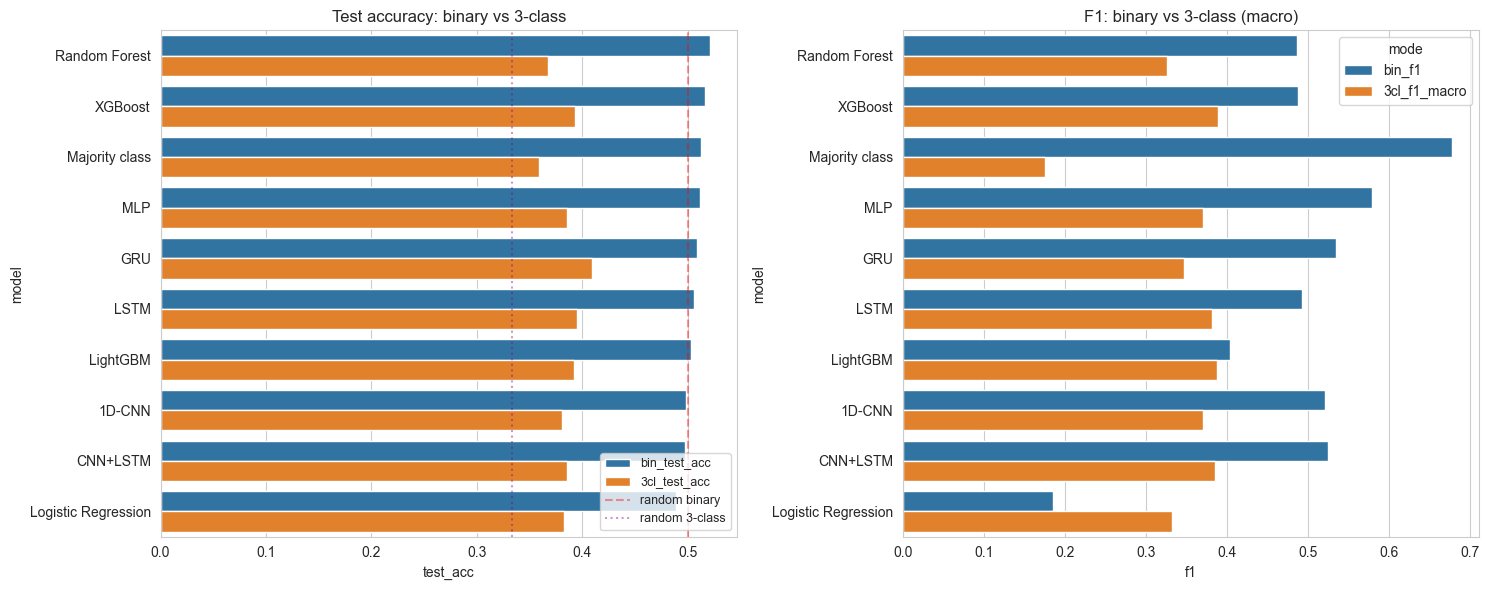

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v3_v3\binary_vs_3class.png


In [30]:
# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
melted_acc = comp.melt(id_vars="model", value_vars=["bin_test_acc","3cl_test_acc"],
                       var_name="mode", value_name="test_acc")
sns.barplot(data=melted_acc, x="test_acc", y="model", hue="mode", ax=axes[0], palette=["#1f77b4","#ff7f0e"])
axes[0].axvline(0.5, ls="--", c="red", alpha=0.4, label="random binary")
axes[0].axvline(1/3, ls=":", c="purple", alpha=0.4, label="random 3-class")
axes[0].set_title("Test accuracy: binary vs 3-class"); axes[0].legend(loc="lower right", fontsize=9)

melted_f1 = comp.melt(id_vars="model", value_vars=["bin_f1","3cl_f1_macro"],
                      var_name="mode", value_name="f1")
sns.barplot(data=melted_f1, x="f1", y="model", hue="mode", ax=axes[1], palette=["#1f77b4","#ff7f0e"])
axes[1].set_title("F1: binary vs 3-class (macro)")
plt.tight_layout()
plt.savefig(ARTIFACTS / "binary_vs_3class.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'binary_vs_3class.png'}")

## 18. Confusion matrices (beide modes)

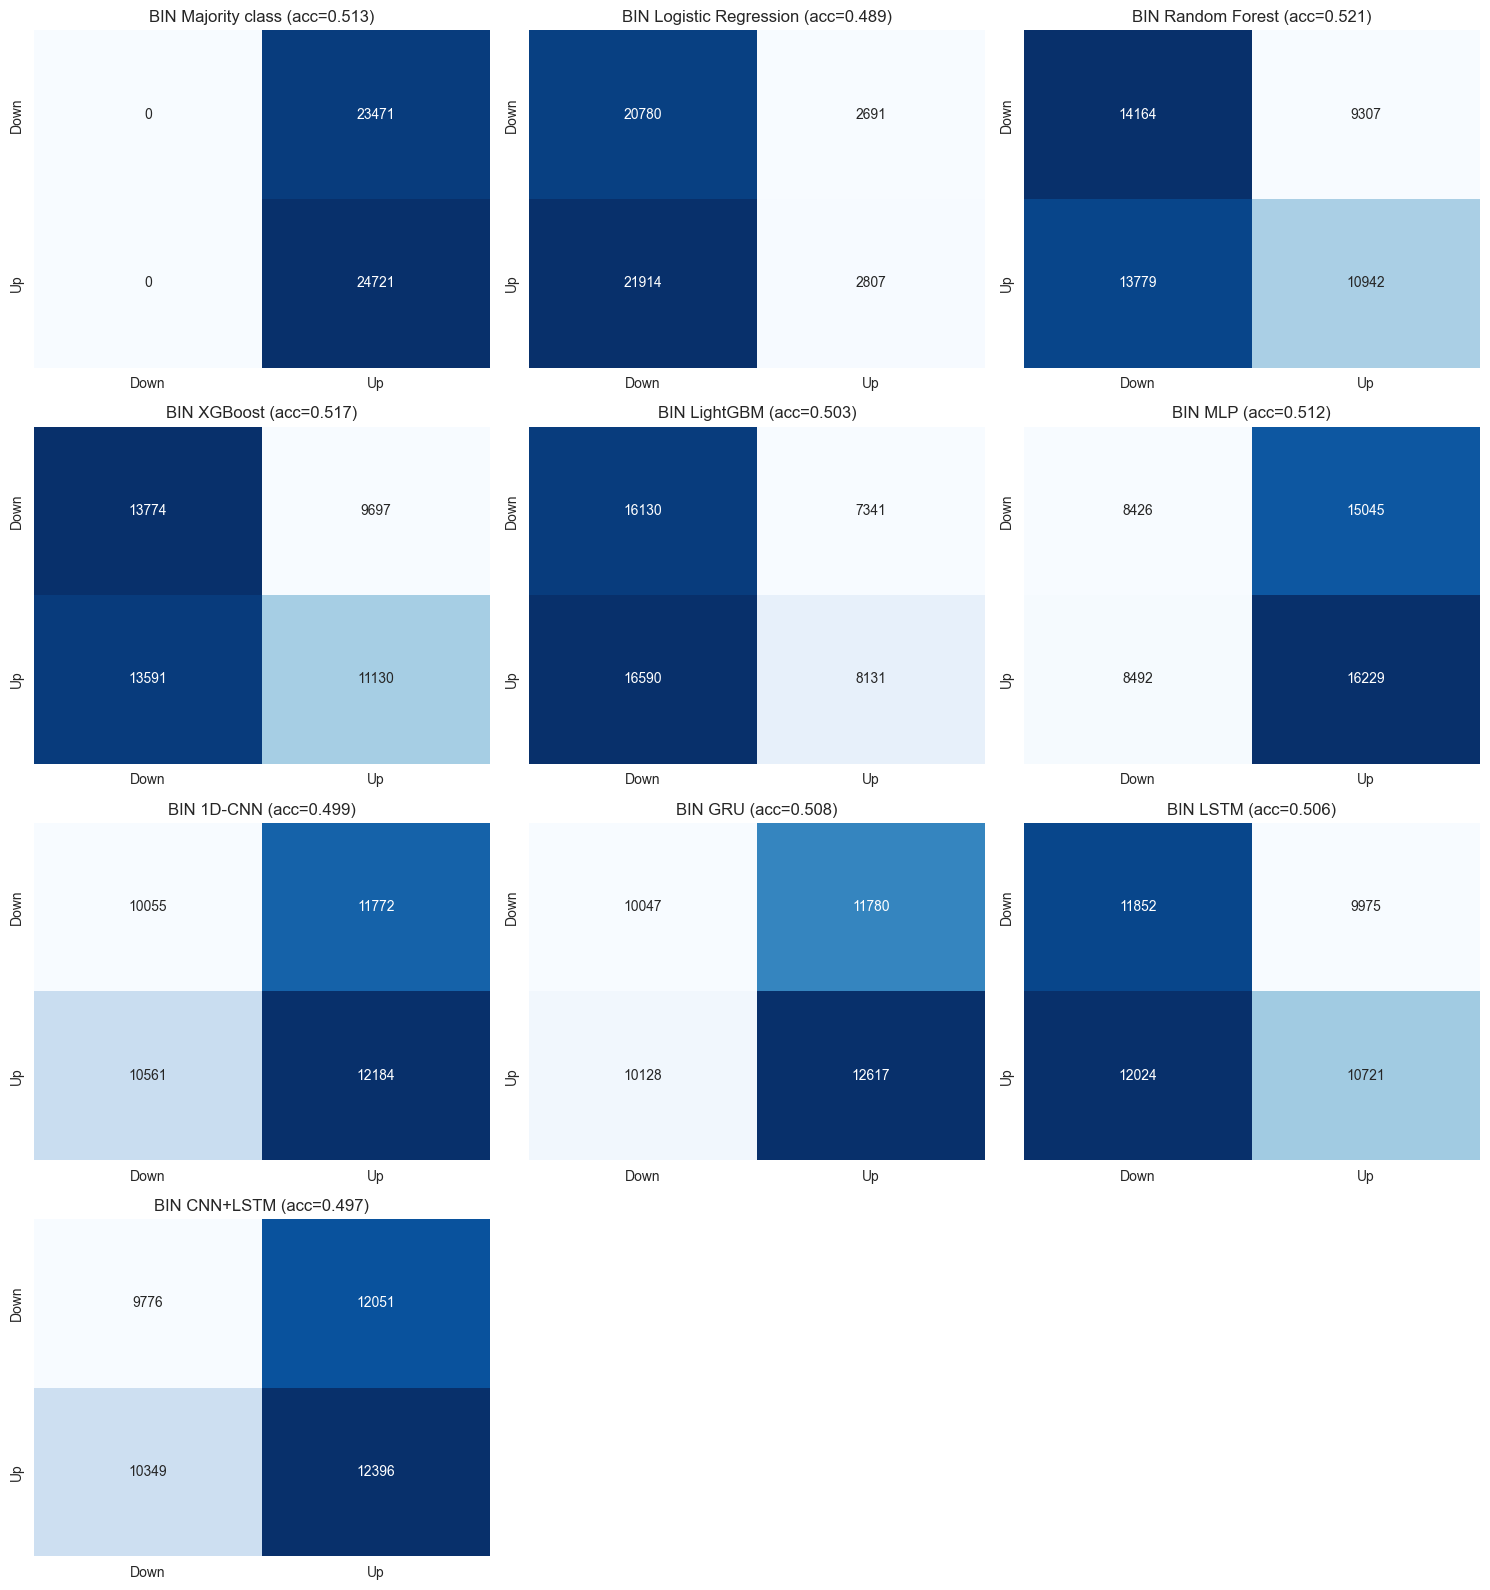

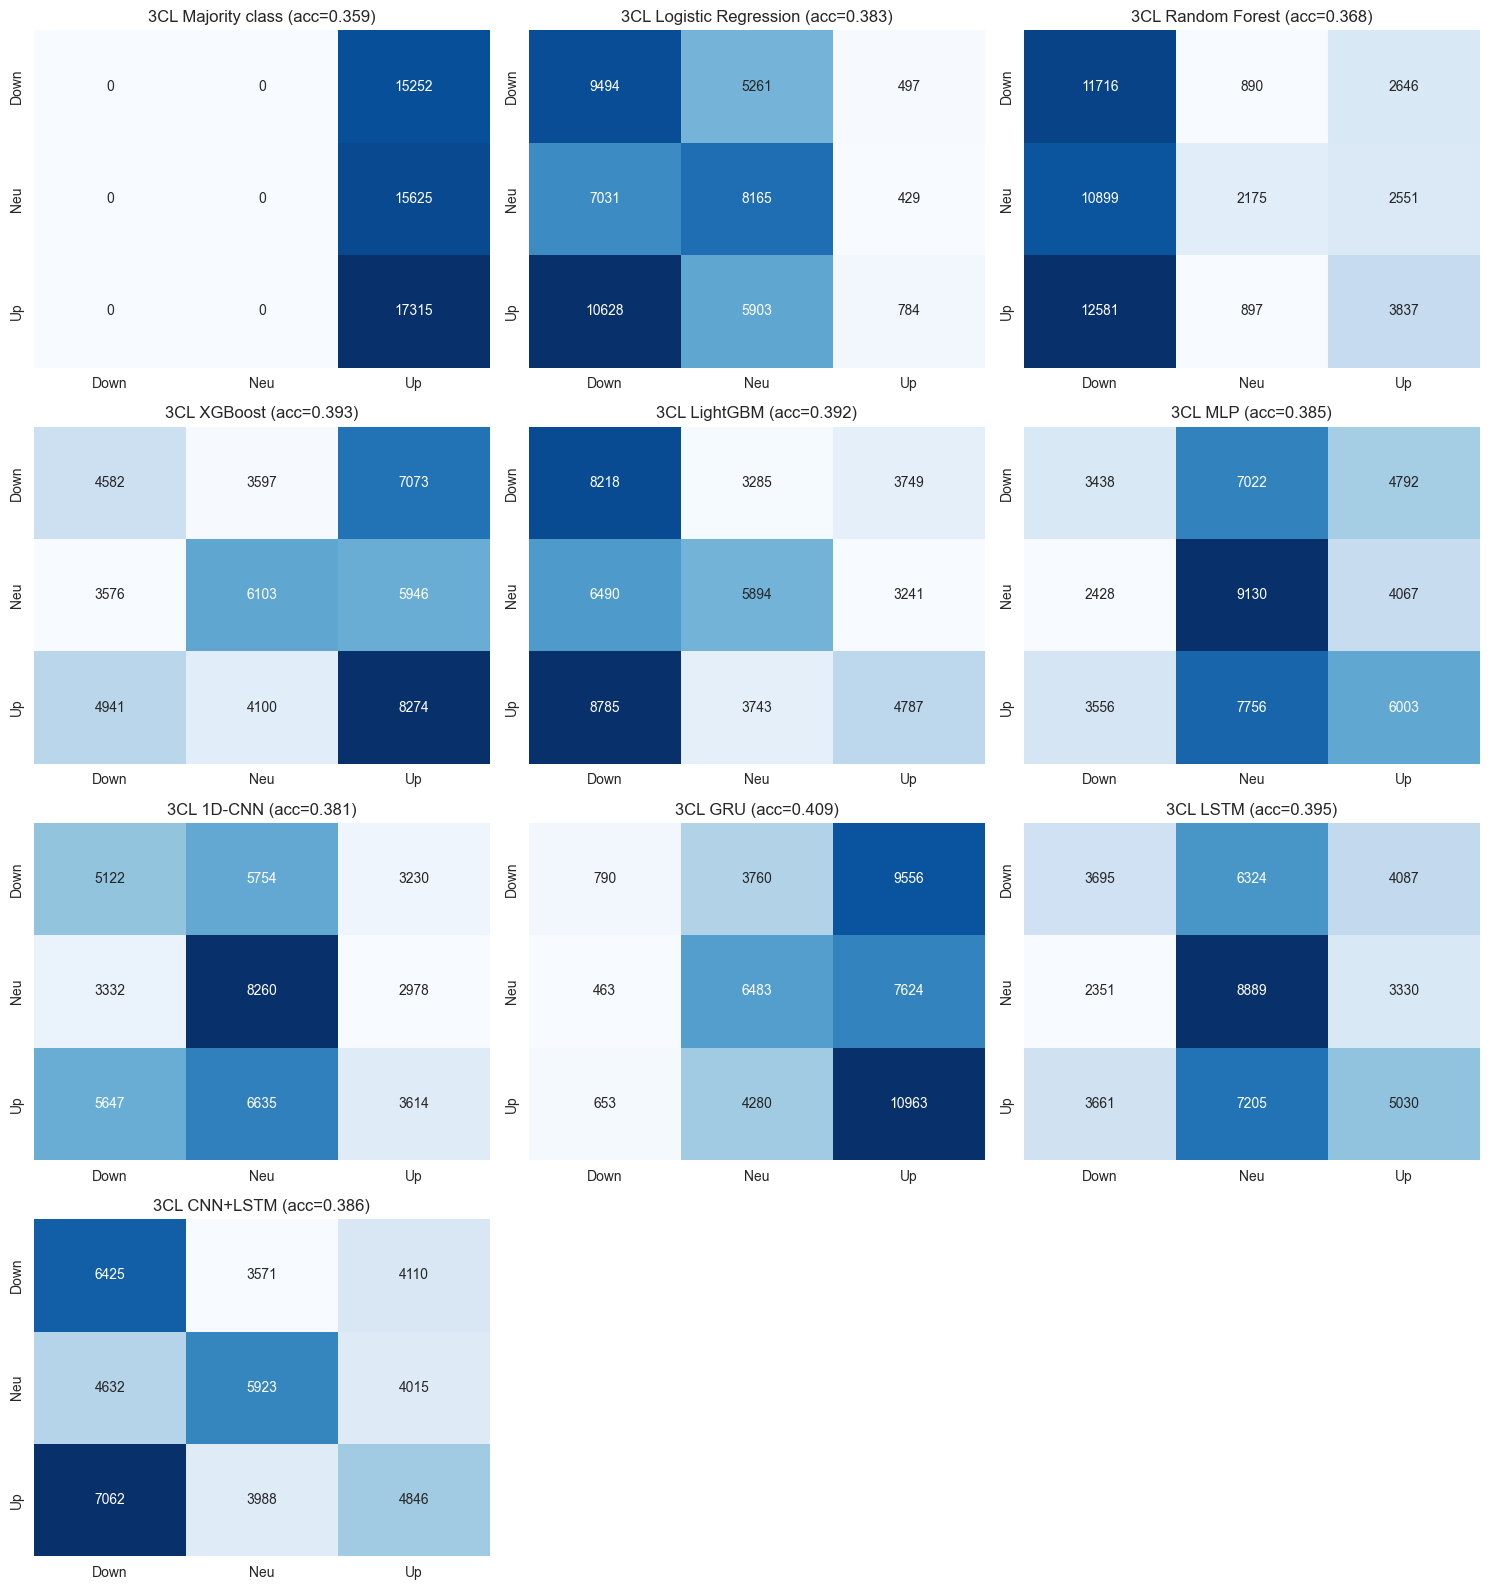

Saved: confusion_binary.png + confusion_3class.png


In [31]:
# Binary
n = len(predictions_bin); ncols = 3; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, (name, p) in zip(axes, predictions_bin.items()):
    cm = confusion_matrix(p["y_true"], p["y_pred"], labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Down","Up"], yticklabels=["Down","Up"], cbar=False)
    acc = accuracy_score(p["y_true"], p["y_pred"])
    ax.set_title(f"BIN {name} (acc={acc:.3f})")
for ax in axes[n:]: ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_binary.png", dpi=120, bbox_inches="tight")
plt.show()

# 3-class
n = len(predictions_3); ncols = 3; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, (name, p) in zip(axes, predictions_3.items()):
    cm = confusion_matrix(p["y_true"], p["y_pred"], labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Down","Neu","Up"], yticklabels=["Down","Neu","Up"], cbar=False)
    acc = accuracy_score(p["y_true"], p["y_pred"])
    ax.set_title(f"3CL {name} (acc={acc:.3f})")
for ax in axes[n:]: ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_3class.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: confusion_binary.png + confusion_3class.png")

## 19. Per-stock plots: werkelijkheid vs voorspelling (BINARY)

KeyboardInterrupt: 

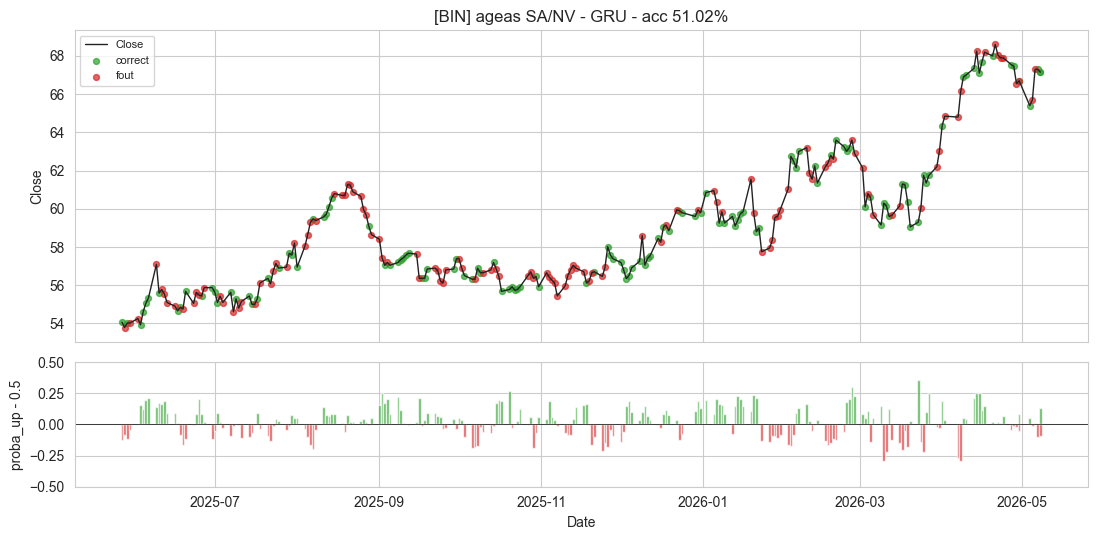

In [32]:
def plot_stock(model_name, stock, sub, out_dir, mode="bin"):
    sub = sub.sort_values("Date").reset_index(drop=True)
    if len(sub) < 2 or sub["Close"].isna().all():
        return None
    correct = (sub["y_true"] == sub["y_pred"]).astype(int)
    acc = correct.mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5),
                                    gridspec_kw={"height_ratios":[2.5,1]}, sharex=True)
    ax1.plot(sub["Date"], sub["Close"], color="#222", lw=1.0, label="Close")
    ok  = sub[correct == 1]
    bad = sub[correct == 0]
    ax1.scatter(ok["Date"],  ok["Close"],  color="#2ca02c", s=18, alpha=0.7, label="correct")
    ax1.scatter(bad["Date"], bad["Close"], color="#d62728", s=18, alpha=0.7, label="fout")
    ax1.legend(loc="upper left", fontsize=8); ax1.set_ylabel("Close")
    ax1.set_title(f"[{mode.upper()}] {stock} - {model_name} - acc {acc:.2%}")
    if mode == "bin":
        colors = ["#d62728" if v < 0.5 else "#2ca02c" for v in sub["y_proba"]]
        ax2.bar(sub["Date"], sub["y_proba"] - 0.5, color=colors, width=1.0, alpha=0.7)
        ax2.axhline(0, color="black", lw=0.5); ax2.set_ylim(-0.5, 0.5)
        ax2.set_ylabel("proba_up - 0.5")
    else:
        # 3-class: stacked bars showing predicted probability per class
        if sub["y_proba_mat"].iloc[0] is not None:
            mat = np.stack(sub["y_proba_mat"].values)
            ax2.fill_between(sub["Date"], 0, mat[:,0], color="#d62728", alpha=0.5, label="down")
            ax2.fill_between(sub["Date"], mat[:,0], mat[:,0]+mat[:,1], color="#7f7f7f", alpha=0.5, label="neu")
            ax2.fill_between(sub["Date"], mat[:,0]+mat[:,1], 1.0, color="#2ca02c", alpha=0.5, label="up")
            ax2.set_ylabel("class proba"); ax2.set_ylim(0,1); ax2.legend(loc="upper right", fontsize=7)
    ax2.set_xlabel("Date")
    plt.tight_layout()
    out = out_dir / f"{re.sub(r'[^A-Za-z0-9_-]', '_', stock)}.png"
    plt.savefig(out, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return acc

PER_STOCK_BIN = PER_STOCK / "binary"
PER_STOCK_3   = PER_STOCK / "3class"
PER_STOCK_BIN.mkdir(parents=True, exist_ok=True)
PER_STOCK_3.mkdir(parents=True, exist_ok=True)

per_stock_bin = []
for model_name, p in predictions_bin.items():
    out_dir = PER_STOCK_BIN / re.sub(r"[^A-Za-z0-9_-]", "_", model_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_df = pd.DataFrame({
        "stock_id": p["stock_id"], "Date": pd.to_datetime(p["Date"]), "Close": p["Close"],
        "y_true": p["y_true"], "y_pred": p["y_pred"], "y_proba": p["y_proba"],
    })
    for stock, sub in plot_df.groupby("stock_id"):
        acc = plot_stock(model_name, stock, sub, out_dir, mode="bin")
        if acc is not None:
            per_stock_bin.append({"model": model_name, "stock": stock, "n": len(sub), "acc": acc})
print(f"Binary plots: {len(per_stock_bin)}")

### 19b. Per-stock plots (3-CLASS)

In [34]:
per_stock_3 = []
for model_name, p in predictions_3.items():
    out_dir = PER_STOCK_3 / re.sub(r"[^A-Za-z0-9_-]", "_", model_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_df = pd.DataFrame({
        "stock_id": p["stock_id"], "Date": pd.to_datetime(p["Date"]), "Close": p["Close"],
        "y_true": p["y_true"], "y_pred": p["y_pred"],
    })
    # Voor 3-class: voeg matrix-proba toe als ze bestaan
    proba_mat = p.get("y_proba")
    if proba_mat is not None and proba_mat.ndim == 2:
        plot_df["y_proba_mat"] = list(proba_mat)
    else:
        plot_df["y_proba_mat"] = [None] * len(plot_df)
    for stock, sub in plot_df.groupby("stock_id"):
        acc = plot_stock(model_name, stock, sub, out_dir, mode="3cl")
        if acc is not None:
            per_stock_3.append({"model": model_name, "stock": stock, "n": len(sub), "acc": acc})
print(f"3-class plots: {len(per_stock_3)}")

3-class plots: 1810


## 20. Per-stock heatmaps

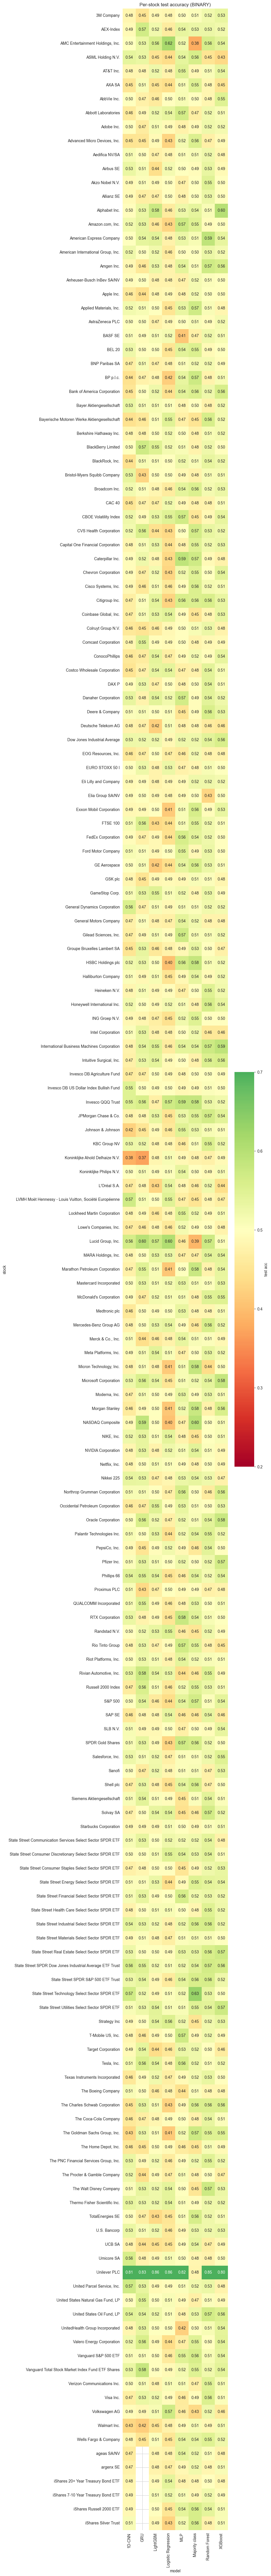

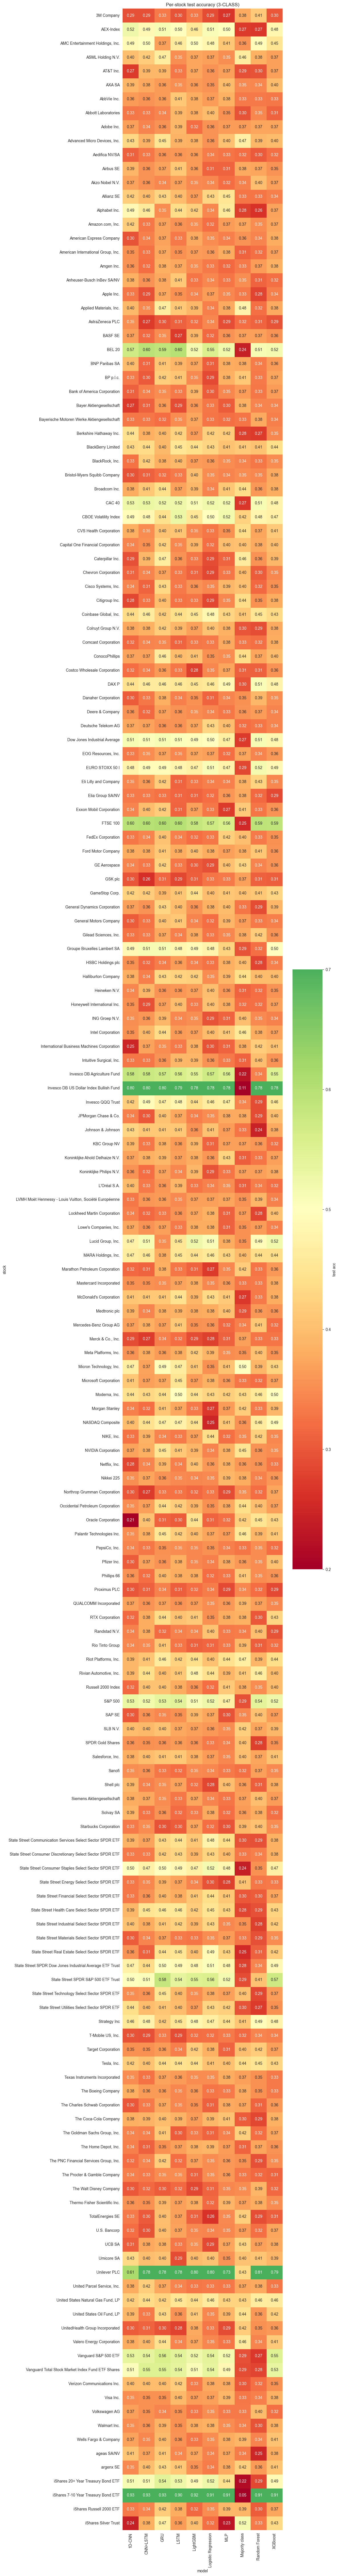

In [35]:
def heatmap_per_stock(records, title, fname):
    if not records: return
    df_p = pd.DataFrame(records)
    pivot = df_p.pivot(index="stock", columns="model", values="acc")
    fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1]*1.2), max(5, pivot.shape[0]*0.5)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
                vmin=0.2, vmax=0.7, ax=ax, cbar_kws={"label":"test acc"})
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / fname, dpi=120, bbox_inches="tight")
    plt.show()

heatmap_per_stock(per_stock_bin, "Per-stock test accuracy (BINARY)", "heatmap_binary.png")
heatmap_per_stock(per_stock_3,   "Per-stock test accuracy (3-CLASS)", "heatmap_3class.png")

## 21. Conclusie

### Wat we in V3 hebben toegevoegd

**1. LLM-based tweet → stock impact scoring**

We gebruiken `sentence-transformers/all-MiniLM-L6-v2` als lichtgewicht
"LLM" om elke tweet te scoren tegen elke stock-descriptor (StockName +
ticker + type). Cosine similarity tussen tweet-embedding en stock-embedding
geeft een impact-score in [0, 1]. Een ticker- of naam-mention boost de
score naar ≥0.95 (dat is een betrouwbaarder signaal dan pure embedding-
similariteit). Sentiment wordt vervolgens **per (Date, stock)** geaggregeerd,
gewogen door deze impact-scores — dus een tweet over Apple weegt sterk in
Apple's sentiment, maar nauwelijks in Tesla's.

Dit fixt de grootste limitatie van V2: daar was sentiment market-wide en
voor elke stock op dag X identiek.

**2. Binary vs 3-class vergelijking**

We vervangen de single binary target met **twee parallelle targets**:
- `target_bin`: 1 = up, 0 = down
- `target_3`: 0 = down (return < -0.5%), 1 = neutral, 2 = up (return > +0.5%)

Alle modellen worden in beide modes getraind. Sectie 17 zet de resultaten
side-by-side.

### Wat te verwachten in de resultaten

**Binary (2-class)**:
- Random baseline = 0.50
- Gradient boosting typisch 0.53-0.56
- Sequence models 0.50-0.54
- De stock-aware sentiment uit de LLM scoring zou hier **enkele
  procentpunten boost** moeten geven boven V2 — vooral op stocks die
  veel direct genoemd worden in tweets

**3-class**:
- Random baseline = 0.33
- Verwacht test accuracy van ~0.40-0.50 — lager dan binary in absolute
  termen, **maar** met meer informatie omdat we onderscheid maken tussen
  "echte beweging" en "ruis rond nul"
- F1-macro is hier een betere metric dan accuracy: een model dat altijd
  "neutral" voorspelt scoort hoog op accuracy maar krijgt lage macro-F1
- 3-class is **conservatiever**: de neutral klasse vangt de vele kleine
  random walks op die in binary-mode als noise meetelden

### Wanneer is welk target beter?

**Binary** is beter wanneer:
- Je een directionele trade-strategie wil bouwen (long/short, geen hold)
- Je accuracy als hoofd-metric optimaliseert
- Eenvoud en interpreteerbaarheid belangrijk zijn

**3-class** is beter wanneer:
- Je transactiekosten serieus neemt — alleen handelen als de voorspelling
  *significant* up of down is (klasse 0 of 2, niet klasse 1)
- Je risk-management belangrijk vindt
- Je realistische evaluatie wil van wat het model écht kan voorspellen
  (kleine bewegingen zijn vaak ruis)
- F1-macro hoger is in 3-class dan binary F1 op de extreme-richting klasses,
  betekent dat het model wel degelijk de echte bewegingen herkent

### Toegevoegde waarde van de LLM impact scoring

Vergelijk `results_bin_df` van V3 met de overeenkomstige V2 cijfers (uit
`artifacts_v2/results.csv`). Als V3 ~1-3 procentpunten hoger scoort, weet
je dat stock-specifieke sentiment-features de moeite waard zijn. Als er
geen verschil is, dan was het sentiment op deze data toch te zwak om
impact-weighted aggregatie te doen werken — wat ook een waardevol resultaat is
voor je bachelorproef-discussie.

### Beperkingen

- **Sentence-transformer ≠ echte LLM**: voor productie zou je een
  finetuned domain model willen (FinBERT, BloombergGPT) of een echte
  LLM-API met prompt engineering. Cosine similarity is een proxy.
- **News blijft market-wide**: nieuws-headlines zijn vaker "Apple beats
  earnings" met expliciete ticker-mention en zouden eigenlijk ook
  per-stock geaggregeerd moeten worden. Dat is een easy follow-up.
- **3-class threshold (0.5%) is willekeurig**: je zou een grid search
  kunnen doen op verschillende thresholds (0.25%, 0.5%, 1%) om de beste
  signal-to-noise te vinden.
- **Class imbalance in 3-class**: typisch is "neutral" de grootste klasse
  op daily timeframe — dat verklaart waarom het model er soms toe neigt
  alles als neutral te voorspellen.

### Volgende stappen

1. **Stock-aware news sentiment**: pas dezelfde LLM-impact scoring toe op
   nieuws-headlines.
2. **Threshold tuning**: probeer THRESHOLD_NEUTRAL = 0.0025, 0.0075, 0.01.
3. **Echte LLM voor moeilijke gevallen**: gebruik OpenAI/Anthropic API
   alleen voor tweets waar de sentence-transformer onzeker is (impact
   tussen 0.3 en 0.7).
4. **Ordinale 3-class**: target_3 is ordinaal (down < neutral < up); een
   model met `OrdinalClassifier` of een regressie op `y_return` met
   discretisatie achteraf kan beter werken.
5. **Backtest met transactiekosten** waar je alleen handelt op
   high-confidence up/down voorspellingen (ignore neutral).
